## Combining Sentiment and Market Data

I have now undertaken the sentiment analysis of news articles and have explored the returns over the same time range. Now I want to combine the data in the format of input and output and split this data into a training (training + dev-test?) as well as the test set (2021).


* Combine relevant market data
     * (Regression or Classification) Probably too noisy to look at % gains. Maybe boolean for gain over next 1,3,5 day period?
* Look at what to include in terms of sentiment
    - Try with negative and compound
    - Positive and compound
    - All the tags

In [29]:
import pandas as pd
import numpy as np

In [11]:
daily_sentiments = pd.read_csv('../sentiment_analysis/daily_sentiments.csv')

In [12]:
daily_sentiments

,date,title_neg,title_neu,title_pos,title_compound,desc_neg,desc_neu,desc_pos,desc_compound
0,2021-04-16,0.092604,0.793604,0.113792,0.025758,0.069083,0.842917,0.087979,0.067115
1,2021-04-15,0.062340,0.840470,0.097190,0.053673,0.054310,0.856250,0.089450,0.156695
2,2021-04-14,0.098358,0.817979,0.083674,-0.026956,0.064200,0.859800,0.076021,0.104177
3,2021-04-13,0.052677,0.869277,0.078015,0.051142,0.056985,0.867354,0.075646,0.106286
4,2021-04-12,0.049151,0.837890,0.112959,0.094377,0.059178,0.864027,0.076808,0.040249
...,...,...,...,...,...,...,...,...,...
1118,2018-03-24,0.101455,0.806364,0.092182,0.005636,0.070364,0.861818,0.067818,-0.077764
1119,2018-03-23,0.101315,0.801315,0.097370,-0.011381,0.063222,0.843093,0.093704,0.155633
1120,2018-03-22,0.117712,0.794685,0.087616,-0.034803,0.063425,0.859425,0.077082,0.056668
1121,2018-03-21,0.076710,0.839177,0.084113,0.014061,0.047355,0.875855,0.076774,0.115885


In order not to work with too many columns I will be combining the sentiments from the title and the description

In [24]:
daily_sentiments['combined compound'] = (daily_sentiments['title_compound'] + daily_sentiments['desc_compound']) / 2
daily_sentiments

,date,title_neg,title_neu,title_pos,title_compound,desc_neg,desc_neu,desc_pos,desc_compound,combined compound
0,2021-04-16,0.092604,0.793604,0.113792,0.025758,0.069083,0.842917,0.087979,0.067115,0.046436
1,2021-04-15,0.062340,0.840470,0.097190,0.053673,0.054310,0.856250,0.089450,0.156695,0.105184
2,2021-04-14,0.098358,0.817979,0.083674,-0.026956,0.064200,0.859800,0.076021,0.104177,0.038611
3,2021-04-13,0.052677,0.869277,0.078015,0.051142,0.056985,0.867354,0.075646,0.106286,0.078714
4,2021-04-12,0.049151,0.837890,0.112959,0.094377,0.059178,0.864027,0.076808,0.040249,0.067313
...,...,...,...,...,...,...,...,...,...,...
1118,2018-03-24,0.101455,0.806364,0.092182,0.005636,0.070364,0.861818,0.067818,-0.077764,-0.036064
1119,2018-03-23,0.101315,0.801315,0.097370,-0.011381,0.063222,0.843093,0.093704,0.155633,0.072126
1120,2018-03-22,0.117712,0.794685,0.087616,-0.034803,0.063425,0.859425,0.077082,0.056668,0.010933
1121,2018-03-21,0.076710,0.839177,0.084113,0.014061,0.047355,0.875855,0.076774,0.115885,0.064973


In [25]:
daily_sentiments['combined negative'] = (daily_sentiments['title_neg'] + daily_sentiments['desc_neg']) / 2
daily_sentiments['combined positive'] = (daily_sentiments['title_pos'] + daily_sentiments['desc_pos']) / 2

daily_sentiments = daily_sentiments[['date', 'combined compound', 'combined positive', 'combined negative']]
daily_sentiments

,date,combined compound,combined positive,combined negative
0,2021-04-16,0.046436,0.100885,0.080844
1,2021-04-15,0.105184,0.093320,0.058325
2,2021-04-14,0.038611,0.079847,0.081279
3,2021-04-13,0.078714,0.076831,0.054831
4,2021-04-12,0.067313,0.094884,0.054164
...,...,...,...,...
1118,2018-03-24,-0.036064,0.080000,0.085909
1119,2018-03-23,0.072126,0.095537,0.082269
1120,2018-03-22,0.010933,0.082349,0.090568
1121,2018-03-21,0.064973,0.080444,0.062032


In order to get a performance measure, I will be looking at the market returns 1 day ahead, 3 days ahead, 5 days ahead, and 10 days ahead.

In [95]:
combined_market_data = pd.read_csv('../data/calculations/combined_market_data.csv')
combined_market_data = combined_market_data[['Date','Formatted Change','Volume', 'Annualised']]
combined_market_data.columns = ['Date', 'Close-Close Change', 'Volume', 'Annualised 30D Volatility']
combined_market_data

,Date,Close-Close Change,Volume,Annualised 30D Volatility
0,2017-01-04,1.005722,3764890000,NaN
1,2017-01-05,0.999229,3761820000,NaN
2,2017-01-06,1.003517,3339890000,NaN
3,2017-01-09,0.996451,3217610000,NaN
4,2017-01-10,1.000000,3638790000,NaN
...,...,...,...,...
1073,2021-04-12,0.999804,3578500000,0.152654
1074,2021-04-13,1.003295,3728440000,0.139007
1075,2021-04-14,0.995912,3976540000,0.136951
1076,2021-04-15,1.011094,4027680000,0.131398


The vol was done on the 30D of the market, the 1,3,5, and 10 day performance will also be using the market open days compared to the whole year.

In [96]:
# Next day
combined_market_data['Future 1D'] = np.nan
for i in range(0,1077):
    combined_market_data['Future 1D'].iloc[i] = combined_market_data['Close-Close Change'].iloc[i+1]
combined_market_data

/Users/oenmalm/anaconda3/lib/python3.8/site-packages/pandas/core/indexing.py:671: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_with_indexer(indexer, value)


,Date,Close-Close Change,Volume,Annualised 30D Volatility,Future 1D
0,2017-01-04,1.005722,3764890000,NaN,0.999229
1,2017-01-05,0.999229,3761820000,NaN,1.003517
2,2017-01-06,1.003517,3339890000,NaN,0.996451
3,2017-01-09,0.996451,3217610000,NaN,1.000000
4,2017-01-10,1.000000,3638790000,NaN,1.002830
...,...,...,...,...,...
1073,2021-04-12,0.999804,3578500000,0.152654,1.003295
1074,2021-04-13,1.003295,3728440000,0.139007,0.995912
1075,2021-04-14,0.995912,3976540000,0.136951,1.011094
1076,2021-04-15,1.011094,4027680000,0.131398,1.003609


In [97]:
# Simple impementation. For the 3 data points we need we could lower the amount of computation required by taking the already 
# calculated and compounding the next x along with it. For code comprehension and ease there is redundancy.
def future_forecast(num_days):
    column_name = 'Future {}D'.format(num_days)
    combined_market_data[column_name] = np.nan
    for i in range(0, len(combined_market_data) - (num_days)):
        # Takes the next num_days and takes the value of the cumulative product of the last day
        result = combined_market_data['Close-Close Change'].iloc[i + 1: i + 1 + num_days].cumprod()[i + num_days]
        combined_market_data[column_name].iloc[i] = result
        
        
future_forecast(3)
future_forecast(5)
future_forecast(10)
combined_market_data

/Users/oenmalm/anaconda3/lib/python3.8/site-packages/pandas/core/indexing.py:671: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_with_indexer(indexer, value)


,Date,Close-Close Change,Volume,Annualised 30D Volatility,Future 1D,Future 3D,Future 5D,Future 10D
0,2017-01-04,1.005722,3764890000,NaN,0.999229,0.999185,1.002013,0.996891
1,2017-01-05,0.999229,3761820000,NaN,1.003517,0.999956,1.000635,1.001018
2,2017-01-06,1.003517,3339890000,NaN,0.996451,0.999271,0.998972,0.994826
3,2017-01-09,0.996451,3217610000,NaN,1.000000,1.000679,0.999555,1.004923
4,2017-01-10,1.000000,3638790000,NaN,1.002830,1.002530,1.001318,1.012989
...,...,...,...,...,...,...,...,...
1073,2021-04-12,0.999804,3578500000,0.152654,1.003295,1.010279,NaN,NaN
1074,2021-04-13,1.003295,3728440000,0.139007,0.995912,1.010595,NaN,NaN
1075,2021-04-14,0.995912,3976540000,0.136951,1.011094,NaN,NaN,NaN
1076,2021-04-15,1.011094,4027680000,0.131398,1.003609,NaN,NaN,NaN


In [99]:
model_data = combined_market_data.copy()

In [100]:
# There are news stories for days that the markets are closed. Using the option inner, will give us only the days where the markets were open
model_data.set_index('Date', inplace=True)
daily_sentiments.set_index('date', inplace=True)

model_data = model_data.join(daily_sentiments, how='inner')
model_data

,Close-Close Change,Volume,Annualised 30D Volatility,Future 1D,Future 3D,Future 5D,Future 10D,combined compound,combined positive,combined negative
2018-03-20,1.001482,3261030000,0.189751,0.998156,0.952638,0.961604,0.973408,-0.041961,0.069304,0.088679
2018-03-21,0.998156,3415510000,0.183278,0.974837,0.980317,0.960571,0.981899,0.064973,0.080444,0.062032
2018-03-22,0.974837,3739800000,0.197111,0.979033,0.988247,0.998933,0.985165,0.010933,0.082349,0.090568
2018-03-23,0.979033,3815080000,0.174543,1.027157,1.006468,0.997535,1.009620,0.072126,0.095537,0.082269
2018-03-26,1.027157,3511100000,0.186708,0.982724,0.993350,0.983412,0.999368,0.026141,0.099982,0.084573
...,...,...,...,...,...,...,...,...,...,...
2021-04-12,0.999804,3578500000,0.152654,1.003295,1.010279,NaN,NaN,0.067313,0.094884,0.054164
2021-04-13,1.003295,3728440000,0.139007,0.995912,1.010595,NaN,NaN,0.078714,0.076831,0.054831
2021-04-14,0.995912,3976540000,0.136951,1.011094,NaN,NaN,NaN,0.038611,0.079847,0.081279
2021-04-15,1.011094,4027680000,0.131398,1.003609,NaN,NaN,NaN,0.105184,0.093320,0.058325


In [103]:
model_data.iloc[-30:]

,Close-Close Change,Volume,Annualised 30D Volatility,Future 1D,Future 3D,Future 5D,Future 10D,combined compound,combined positive,combined negative
2021-03-05,1.019496,6842570000,0.186793,0.994641,1.014802,1.026393,1.018522,0.057052,0.092690,0.075983
2021-03-08,0.994641,5852240000,0.187242,1.014155,1.030877,1.038622,1.031204,0.050615,0.076700,0.048564
2021-03-09,1.014155,5496340000,0.191506,1.006030,1.017521,1.022519,1.009052,0.038429,0.075686,0.071686
2021-03-10,1.006030,5827250000,0.192154,1.010395,1.017988,1.019316,0.997520,0.133384,0.109183,0.050805
2021-03-11,1.010395,5300010000,0.177329,1.001015,1.005932,0.993938,0.992430,0.050990,0.093729,0.077367
2021-03-12,1.001015,4469240000,0.175677,1.006492,1.007806,0.992331,1.007912,-0.036615,0.062028,0.075549
2021-03-15,1.006492,4882190000,0.164818,0.998430,0.986525,0.992857,1.000542,0.029539,0.076830,0.065312
2021-03-16,0.998430,4604870000,0.159848,1.002879,0.987481,0.986830,0.998950,0.027153,0.077500,0.064227
2021-03-17,1.002879,4541620000,0.155663,0.985239,0.991563,0.978617,0.999690,0.041350,0.089182,0.066797
2021-03-18,0.985239,4043170000,0.162489,0.999397,0.998738,0.998483,1.026666,0.043674,0.082734,0.071661


## Decision on data to use

* The final set of data will contain the trading days in the range of 20.3.2018 to (inclusive) 1.4.2021
* Using information theory, will help me decide which of the columns have the most predictive potential

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif

In [106]:
model_data = model_data.loc['2018-03-20':'2021-04-01']

In [107]:
model_data.head(1)

,Close-Close Change,Volume,Annualised 30D Volatility,Future 1D,Future 3D,Future 5D,Future 10D,combined compound,combined positive,combined negative
2018-03-20,1.001482,3261030000,0.189751,0.998156,0.952638,0.961604,0.973408,-0.041961,0.069304,0.088679


In [118]:
# The inputs are the values that we know the current day
inputs = model_data[['combined compound', 'combined positive', 'combined negative', 'Annualised 30D Volatility']]

# All of the future information pertaining to a given day
outputs = model_data[['Future 1D', 'Future 3D', 'Future 5D', 'Future 10D']]

In [110]:
%matplotlib inline
sns.set_style('whitegrid')
idx = pd.IndexSlice

/Users/oenmalm/anaconda3/lib/python3.8/site-packages/seaborn/matrix.py:203: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/oenmalm/anaconda3/lib/python3.8/site-packages/seaborn/matrix.py:208: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


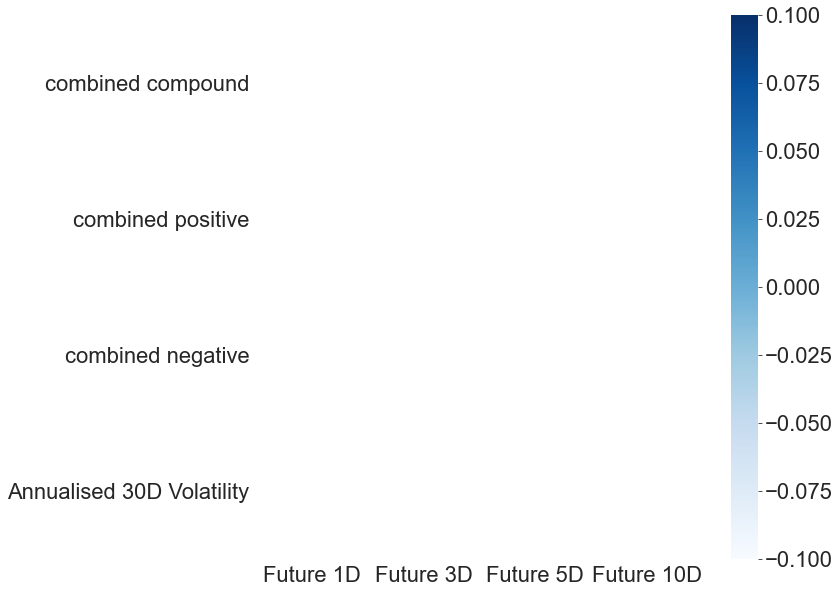

In [197]:
# This code is adapted from Stefan Janssen (2020). 
# It can be found: 
# https://github.com/PacktPublishing/Machine-Learning-for-Algorithmic-Trading-Second-Edition/blob/master/06_machine_learning_process/02_mutual_information.ipynb


def produce_mutal_information_graphic(X, y):
    mutual_information = pd.DataFrame()
    plt.rcParams.update({'font.size': 22})
    for label in y.columns:
        mi = mutual_info_classif(X=X, 
                                 y=(y[label]> 0).astype(int)
                                )    
        mutual_information[label] = pd.Series(mi, index=X.columns)

    fig, ax= plt.subplots(figsize=(10, 10))
    
    sns.heatmap(mutual_information.div(mutual_information.sum()), ax=ax, cmap='Blues')
    
    
produce_mutal_information_graphic(inputs, outputs)    

From this exploration it looks like it is all noise...

Instead of using the actual returns I will evaluate if there is a gain or not.

In [122]:
model_data.head(1)

,Close-Close Change,Volume,Annualised 30D Volatility,Future 1D,Future 3D,Future 5D,Future 10D,combined compound,combined positive,combined negative
2018-03-20,1.001482,3261030000,0.189751,0.998156,0.952638,0.961604,0.973408,-0.041961,0.069304,0.088679


In [124]:
model_data['1D increase'] = model_data['Future 1D'] > 1
model_data.head(5)

<ipython-input-124-a2bc46bf4d7a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_data['1D increase'] = model_data['Future 1D'] > 1


,Close-Close Change,Volume,Annualised 30D Volatility,Future 1D,Future 3D,Future 5D,Future 10D,combined compound,combined positive,combined negative,1D increase
2018-03-20,1.001482,3261030000,0.189751,0.998156,0.952638,0.961604,0.973408,-0.041961,0.069304,0.088679,False
2018-03-21,0.998156,3415510000,0.183278,0.974837,0.980317,0.960571,0.981899,0.064973,0.080444,0.062032,False
2018-03-22,0.974837,3739800000,0.197111,0.979033,0.988247,0.998933,0.985165,0.010933,0.082349,0.090568,False
2018-03-23,0.979033,3815080000,0.174543,1.027157,1.006468,0.997535,1.009620,0.072126,0.095537,0.082269,True
2018-03-26,1.027157,3511100000,0.186708,0.982724,0.993350,0.983412,0.999368,0.026141,0.099982,0.084573,False


In [126]:
model_data['3D increase'] = model_data['Future 3D'] > 1
model_data['5D increase'] = model_data['Future 5D'] > 1
model_data['10D increase'] = model_data['Future 10D'] > 1
model_data.head(5)

<ipython-input-126-1aa46409f4dd>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_data['3D increase'] = model_data['Future 3D'] > 1
<ipython-input-126-1aa46409f4dd>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_data['5D increase'] = model_data['Future 5D'] > 1
<ipython-input-126-1aa46409f4dd>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda

,Close-Close Change,Volume,Annualised 30D Volatility,Future 1D,Future 3D,Future 5D,Future 10D,combined compound,combined positive,combined negative,1D increase,3D increase,5D increase,10D increase
2018-03-20,1.001482,3261030000,0.189751,0.998156,0.952638,0.961604,0.973408,-0.041961,0.069304,0.088679,False,False,False,False
2018-03-21,0.998156,3415510000,0.183278,0.974837,0.980317,0.960571,0.981899,0.064973,0.080444,0.062032,False,False,False,False
2018-03-22,0.974837,3739800000,0.197111,0.979033,0.988247,0.998933,0.985165,0.010933,0.082349,0.090568,False,False,False,False
2018-03-23,0.979033,3815080000,0.174543,1.027157,1.006468,0.997535,1.009620,0.072126,0.095537,0.082269,True,True,False,True
2018-03-26,1.027157,3511100000,0.186708,0.982724,0.993350,0.983412,0.999368,0.026141,0.099982,0.084573,False,False,False,False


In [ ]:
data_2020 = model_data['2020-01-01':'2020-12-31']
data_2020

In [ ]:
rest_data = pd.concat([model_data[:'2020-01-01'], model_data['2020_12-31':]])
rest_data

In [135]:
rest_data.head(1)

,Close-Close Change,Volume,Annualised 30D Volatility,Future 1D,Future 3D,Future 5D,Future 10D,combined compound,combined positive,combined negative,1D increase,3D increase,5D increase,10D increase
2018-03-20,1.001482,3261030000,0.189751,0.998156,0.952638,0.961604,0.973408,-0.041961,0.069304,0.088679,False,False,False,False


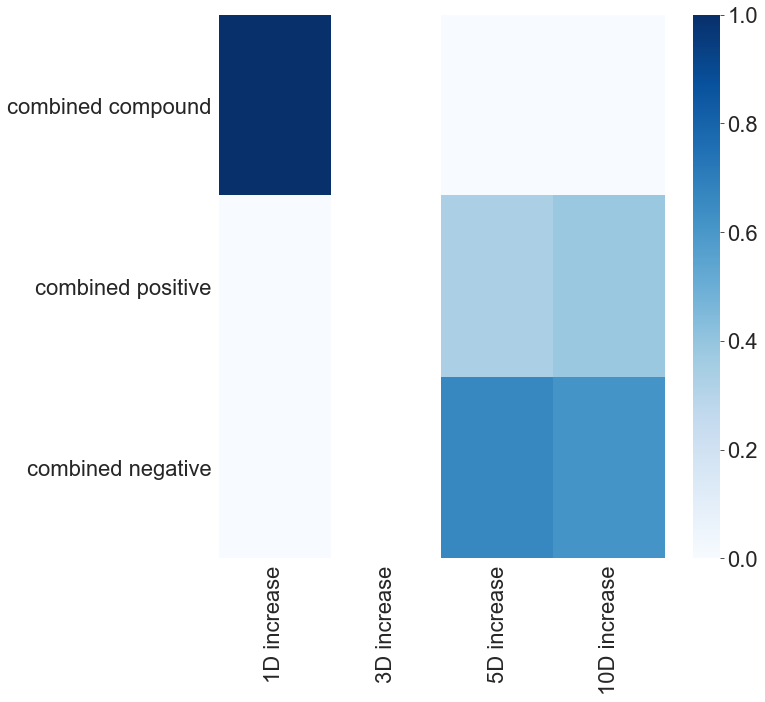

In [198]:
rest_data_semantics = rest_data[['combined compound', 'combined positive', 'combined negative']]
rest_data_outputs = rest_data[['1D increase', '3D increase', '5D increase', '10D increase']]

produce_mutal_information_graphic(rest_data_semantics, rest_data_outputs)

There are colours! Maybe it is worth exploring, especially the one day change!

So, will be using two models.

1. Will be trained using the combined compounds score and look at predicting the next day result (suspiciously high)
2. Will be trained using the combined negatice score and the 5D, 10D changes

rest_data and data_2020

In [140]:
rest_data.head(1)

,Close-Close Change,Volume,Annualised 30D Volatility,Future 1D,Future 3D,Future 5D,Future 10D,combined compound,combined positive,combined negative,1D increase,3D increase,5D increase,10D increase
2018-03-20,1.001482,3261030000,0.189751,0.998156,0.952638,0.961604,0.973408,-0.041961,0.069304,0.088679,False,False,False,False


In [142]:
training_1D_X = rest_data['combined compound']
test_1D_X =  data_2020['combined compound']

training_1D_y = rest_data['1D increase']
test_1D_y = data_2020['1D increase']

training_5_10D_X = rest_data['combined negative']
test_5_10D_X = data_2020['combined negative']

training_5_10D_y = rest_data[['5D increase','10D increase']]
test_5_10D_y = data_2020[['5D increase','10D increase']]

## Training and Testing

In [204]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()

# Example as per documentation on https://scikit-learn.org/stable/modules/naive_bayes.html
gnb_prediction = gnb.fit(training_1D_X.values.reshape(-1, 1), training_1D_y.values.reshape(-1, 1)).predict(test_1D_X.values.reshape(-1, 1))
print("Number of mislabeled points out of a total %d points : %d" % (len(test_1D_X), (gnb_predicition != test_1D_y).sum()))

Number of mislabeled points out of a total 253 points : 109


/Users/oenmalm/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


In [205]:
type_1_error = 0 # (false positive)
type_2_error = 0 # (false negative)
for i in range(0,len(gnb_prediction)):
    if gnb_prediction[i]:
        if not test_1D_y[i]:
            type_1_error += 1
    else:
        if test_1D_y[i]:
            type_2_error += 1

print('Type 1 Error: {} ({})'.format(type_1_error, type_1_error / len(gnb_predicition)))
print('Type 2 Error: {} ({})'.format(type_2_error, type_2_error / len(gnb_predicition)))

Type 1 Error: 109 (0.4308300395256917)
Type 2 Error: 0 (0.0)


In [200]:
gnb_predicition

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [159]:
# So the prediction is just to predict that everything is positive...
print('Negative returns in test set {}'.format(len([negative for negative in test_1D_y if negative == False])))

Negative returns in test set 109


In [170]:
from sklearn.naive_bayes import BernoulliNB
bnb = BernoulliNB()

bnb_prediction = bnb.fit(X=training_1D_X.values.reshape(-1, 1), y=training_1D_y.values.reshape(-1, 1)).predict(test_1D_X.values.reshape(-1, 1))
print("Number of mislabeled points out of a total %d points : %d" % (len(test_1D_X), (bnb_prediction != test_1D_y).sum()))

Number of mislabeled points out of a total 253 points : 109


/Users/oenmalm/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


In [206]:
rest_data_equal_mix = rest_data[['combined compound','1D increase']]
rest_data_equal_mix.reset_index(inplace=True)
rest_data_equal_mix = rest_data_equal_mix.sample(frac=1)
# rest_data_equal_mix

In [177]:
rest_data_equal_mix.sort_values(by=['1D increase'], inplace=True, ignore_index=True)
rest_data_equal_mix

,index,combined compound,1D increase
0,2019-08-02,-0.013299,False
1,2019-02-06,0.134069,False
2,2021-03-23,-0.058159,False
3,2019-12-23,0.018524,False
4,2018-09-25,0.122724,False
...,...,...,...
507,2021-01-11,0.068632,True
508,2019-02-01,0.148222,True
509,2021-02-02,0.013868,True
510,2019-06-27,0.005899,True


In [178]:
positive_negative_100_100 = pd.concat([rest_data_equal_mix[:100], rest_data_equal_mix[-100:]])
len(positive_negative_100_100)

200

## Training with equal weighting

There was only a single feature and the dominant class was chosen. With equal weighting the prediction should hopefully take the features more into account.

In [179]:
equalweight_1D_X = positive_negative_100_100['combined compound'].values.reshape(-1, 1)
equalweight_1D_y = positive_negative_100_100['1D increase'].values.reshape(-1, 1)

equal_weight_nb_prediction = gnb.fit(equalweight_1D_X, equalweight_1D_y).predict(test_1D_X.values.reshape(-1, 1))
print("Number of mislabeled points out of a total %d points : %d" % (len(test_1D_X), (equal_weight_nb_prediction != test_1D_y).sum()))

Number of mislabeled points out of a total 253 points : 126


/Users/oenmalm/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


In [194]:
type_1_error = 0 # (false positive)
type_2_error = 0 # (false negative)
for i in range(0,len(gnb_prediciton)):
    if equal_weight_nb_prediction[i]:
        if not test_1D_y[i]:
            type_1_error += 1
    else:
        if test_1D_y[i]:
            type_2_error += 1

print('Type 1 Error: {} ({})'.format(type_1_error, type_1_error / len(equal_weight_nb_prediction)))
print('Type 2 Error: {} ({})'.format(type_2_error, type_2_error / len(equal_weight_nb_prediction)))

Type 1 Error: 25 (0.09881422924901186)
Type 2 Error: 101 (0.39920948616600793)


So it is 50:50 predictive potential... coin toss

# Checking the 5 and 10 day

In [184]:
training_5_10D_X.head(1)

2018-03-20    0.088679
Name: combined negative, dtype: float64

In [185]:
training_5_10D_y.head(1)

,5D increase,10D increase
2018-03-20,False,False


In [186]:
prediction_5D = gnb.fit(training_5_10D_X.values.reshape(-1, 1), training_5_10D_y['5D increase']).predict(test_5_10D_X.values.reshape(-1, 1))
print("Number of mislabeled points out of a total %d points : %d" % (len(test_5_10D_X), (prediction_5D != test_5_10D_y['5D increase']).sum()))

Number of mislabeled points out of a total 253 points : 94


In [187]:
prediction_5D

array([ True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [188]:
test_5_10D_y['5D increase'].head(2)

2020-01-02    True
2020-01-03    True
Name: 5D increase, dtype: bool

In [189]:
prediction_10D = gnb.fit(training_5_10D_X.values.reshape(-1, 1), training_5_10D_y['10D increase']).predict(test_5_10D_X.values.reshape(-1, 1))
print("Number of mislabeled points out of a total %d points : %d" % (len(test_5_10D_X), (prediction_10D != test_5_10D_y['10D increase']).sum()))

Number of mislabeled points out of a total 253 points : 72


In [190]:
prediction_10D

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [191]:
model_data

,Close-Close Change,Volume,Annualised 30D Volatility,Future 1D,Future 3D,Future 5D,Future 10D,combined compound,combined positive,combined negative,1D increase,3D increase,5D increase,10D increase
2018-03-20,1.001482,3261030000,0.189751,0.998156,0.952638,0.961604,0.973408,-0.041961,0.069304,0.088679,False,False,False,False
2018-03-21,0.998156,3415510000,0.183278,0.974837,0.980317,0.960571,0.981899,0.064973,0.080444,0.062032,False,False,False,False
2018-03-22,0.974837,3739800000,0.197111,0.979033,0.988247,0.998933,0.985165,0.010933,0.082349,0.090568,False,False,False,False
2018-03-23,0.979033,3815080000,0.174543,1.027157,1.006468,0.997535,1.009620,0.072126,0.095537,0.082269,True,True,False,True
2018-03-26,1.027157,3511100000,0.186708,0.982724,0.993350,0.983412,0.999368,0.026141,0.099982,0.084573,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-03-26,1.016631,5467850000,0.169287,0.999132,0.999585,1.026008,1.038608,0.077943,0.090213,0.061994,False,False,True,True
2021-03-29,0.999132,4619840000,0.168866,0.996842,1.012284,1.025900,1.042935,-0.002255,0.075907,0.084160,False,True,True,True
2021-03-30,0.996842,4103570000,0.169156,1.003623,1.030152,1.030668,1.041962,0.046834,0.087266,0.067165,True,True,True,True
2021-03-31,1.003623,4564980000,0.169422,1.011825,1.025435,1.031282,1.049719,0.064380,0.088761,0.067811,True,True,True,True


In [192]:
model_data_returns = model_data.drop(columns=['combined compound', 'combined positive', 'combined negative'])
model_data_returns

,Close-Close Change,Volume,Annualised 30D Volatility,Future 1D,Future 3D,Future 5D,Future 10D,1D increase,3D increase,5D increase,10D increase
2018-03-20,1.001482,3261030000,0.189751,0.998156,0.952638,0.961604,0.973408,False,False,False,False
2018-03-21,0.998156,3415510000,0.183278,0.974837,0.980317,0.960571,0.981899,False,False,False,False
2018-03-22,0.974837,3739800000,0.197111,0.979033,0.988247,0.998933,0.985165,False,False,False,False
2018-03-23,0.979033,3815080000,0.174543,1.027157,1.006468,0.997535,1.009620,True,True,False,True
2018-03-26,1.027157,3511100000,0.186708,0.982724,0.993350,0.983412,0.999368,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
2021-03-26,1.016631,5467850000,0.169287,0.999132,0.999585,1.026008,1.038608,False,False,True,True
2021-03-29,0.999132,4619840000,0.168866,0.996842,1.012284,1.025900,1.042935,False,True,True,True
2021-03-30,0.996842,4103570000,0.169156,1.003623,1.030152,1.030668,1.041962,True,True,True,True
2021-03-31,1.003623,4564980000,0.169422,1.011825,1.025435,1.031282,1.049719,True,True,True,True


In [193]:
model_data_returns.to_csv('../data/calculations/return_intervals_sp500.csv')